In [162]:
import numpy as np 
import pandas as pd 
import statistics as sts 
from matplotlib import pyplot as plt 
import seaborn as sns 
import streamlit as st 
import joblib 
import warnings
from sklearn.preprocessing import StandardScaler,MinMaxScaler,LabelEncoder,OrdinalEncoder,PowerTransformer,PolynomialFeatures
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.impute import SimpleImputer,KNNImputer
from sklearn.metrics import r2_score,mean_absolute_error,mean_absolute_error,root_mean_squared_error
from sklearn.feature_selection import SelectKBest,f_regression
warnings.filterwarnings("ignore")

In [73]:
df=pd.read_csv(r"C:\Shravan\PythonPratice\supervised\machineLearning1\pred13\clothes_price_prediction_data.csv",encoding_errors='ignore')

In [74]:
df1=df.copy()

In [75]:
df1.sample(10)

,Brand,Category,Color,Size,Material,Price
634,Reebok,Sweater,Blue,XL,Denim,119
138,Under Armour,Jacket,Yellow,S,Nylon,20
656,Reebok,Dress,Blue,M,Cotton,84
463,Reebok,Jeans,Red,L,Nylon,185
683,New Balance,Sweater,Red,XS,Polyester,193
563,Nike,Shoes,Red,S,Silk,97
102,Reebok,Jeans,Green,XXL,Nylon,10
383,Nike,T-shirt,Yellow,M,Polyester,127
390,Puma,Jeans,Blue,S,Polyester,65
4,Adidas,Sweater,White,M,Nylon,113


In [76]:
print(df1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Brand     1000 non-null   object
 1   Category  1000 non-null   object
 2   Color     1000 non-null   object
 3   Size      1000 non-null   object
 4   Material  1000 non-null   object
 5   Price     1000 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 47.0+ KB
None


In [83]:
df1.Material.value_counts().to_dict()

{'Polyester': 175,
 'Silk': 173,
 'Wool': 172,
 'Denim': 163,
 'Cotton': 162,
 'Nylon': 155}

In [84]:
Materail_encoded={'Polyester': 0,
 'Silk': 1,
 'Wool': 2,
 'Denim': 3,
 'Cotton': 4,
 'Nylon': 5}

df1['Material_encoded']=df1['Material'].map(Materail_encoded)

In [85]:
df1.Size.value_counts().to_dict()

{'XS': 196, 'XXL': 173, 'XL': 167, 'S': 166, 'M': 157, 'L': 141}

In [86]:
Size_encoded={'XS': 1, 'XXL': 5, 'XL': 4, 'S': 0, 'M': 2, 'L': 3}

df1['Size_encoded']=df1['Size'].map(Size_encoded)

In [87]:
df1.Color.value_counts().to_dict()

{'Yellow': 173,
 'White': 171,
 'Red': 168,
 'Black': 163,
 'Blue': 163,
 'Green': 162}

In [88]:
Color_encoded={'Yellow': 0,
 'White': 1,
 'Red': 2,
 'Black': 3,
 'Blue': 4,
 'Green': 5}

df1['Color_encoded']=df1['Color'].map(Color_encoded)

In [89]:
df1.Category.value_counts().to_dict()

{'Jacket': 191,
 'Shoes': 172,
 'Jeans': 167,
 'Dress': 166,
 'Sweater': 160,
 'T-shirt': 144}

In [90]:
Category_encoded={'Jacket': 0,
 'Shoes': 1,
 'Jeans': 2,
 'Dress': 3,
 'Sweater': 4,
 'T-shirt': 5}

df1['Category_encoded']=df1['Category'].map(Category_encoded)

In [91]:
df1.Brand.value_counts().to_dict()

{'Under Armour': 179,
 'Puma': 168,
 'Adidas': 166,
 'Nike': 165,
 'New Balance': 164,
 'Reebok': 158}

In [92]:
Brand_encoded={'Under Armour': 0,
 'Puma': 1,
 'Adidas': 2,
 'Nike': 3,
 'New Balance': 4,
 'Reebok': 5}

df1['Brand_encoded']=df1['Brand'].map(Brand_encoded)

In [109]:
df1.sample(10)

,Brand,Category,Color,Size,Material,Price,Material_encoded,Size_encoded,Color_encoded,Category_encoded,Brand_encoded
977,Reebok,Dress,Red,XL,Wool,149,2,4,2,3,5
193,Reebok,T-shirt,Green,S,Polyester,127,0,0,5,5,5
769,Puma,Dress,Yellow,XS,Wool,163,2,1,0,3,1
530,Adidas,Dress,Black,M,Nylon,114,5,2,3,3,2
90,Under Armour,Jacket,White,XXL,Silk,196,1,5,1,0,0
889,Under Armour,T-shirt,Yellow,S,Silk,19,1,0,0,5,0
680,Puma,T-shirt,White,L,Wool,174,2,3,1,5,1
914,Reebok,Sweater,Green,S,Cotton,173,4,0,5,4,5
687,Reebok,Shoes,White,S,Nylon,107,5,0,1,1,5
63,Adidas,Sweater,Green,XS,Denim,179,3,1,5,4,2


In [118]:
df2=df1.copy()

In [119]:
cata_col=df1.select_dtypes(include='object',exclude='number').columns
cata_col

Index(['Brand', 'Category', 'Color', 'Size', 'Material'], dtype='object')

In [125]:
df2.drop(columns=['Brand', 'Category', 'Color', 'Size', 'Material'],axis=1,inplace=True)

In [126]:
df2.sample(10)

,Price,Material_encoded,Size_encoded,Color_encoded,Category_encoded,Brand_encoded
770,162,1,0,0,5,4
757,177,1,1,3,1,2
415,32,1,1,5,0,3
619,198,2,5,1,0,1
672,196,1,5,0,3,5
632,111,5,1,4,3,5
489,34,0,4,3,4,4
762,109,2,2,2,3,5
240,158,3,3,1,3,5
673,142,1,2,3,4,4


In [127]:
df2.columns

Index(['Price', 'Material_encoded', 'Size_encoded', 'Color_encoded',
       'Category_encoded', 'Brand_encoded'],
      dtype='object')

In [129]:
df3=pd.DataFrame(data=df2,columns=[ 'Material_encoded', 'Size_encoded', 'Color_encoded',
       'Category_encoded', 'Brand_encoded','Price'])

In [130]:
df3.sample(10)

,Material_encoded,Size_encoded,Color_encoded,Category_encoded,Brand_encoded,Price
719,1,1,4,4,1,47
370,0,2,2,3,5,191
147,2,2,0,0,4,192
744,0,1,5,1,2,126
52,4,4,0,1,1,48
972,3,2,1,3,2,120
977,2,4,2,3,5,149
225,4,2,0,2,2,42
861,5,3,0,1,1,46
404,3,5,2,4,0,187


In [132]:
df3[df3.duplicated()]

,Material_encoded,Size_encoded,Color_encoded,Category_encoded,Brand_encoded,Price


In [133]:
df3.drop_duplicates(df3,inplace=True)

In [134]:
df3.sample(10)

,Material_encoded,Size_encoded,Color_encoded,Category_encoded,Brand_encoded,Price
642,3,1,1,1,5,45
213,1,1,0,0,4,121
375,4,5,0,2,4,183
935,3,0,4,2,2,40
48,1,1,1,2,3,138
999,2,1,0,0,4,174
717,3,4,5,2,5,58
67,1,5,4,2,1,129
918,4,1,1,2,0,122
89,4,1,4,4,0,158


                  Material_encoded  Size_encoded  Color_encoded  \
Material_encoded              1.00         -0.04           0.03   
Size_encoded                 -0.04          1.00           0.04   
Color_encoded                 0.03          0.04           1.00   
Category_encoded             -0.01          0.01          -0.02   
Brand_encoded                 0.01         -0.07          -0.01   
Price                         0.02          0.00          -0.02   

                  Category_encoded  Brand_encoded  Price  
Material_encoded             -0.01           0.01   0.02  
Size_encoded                  0.01          -0.07   0.00  
Color_encoded                -0.02          -0.01  -0.02  
Category_encoded              1.00           0.07   0.02  
Brand_encoded                 0.07           1.00   0.04  
Price                         0.02           0.04   1.00  


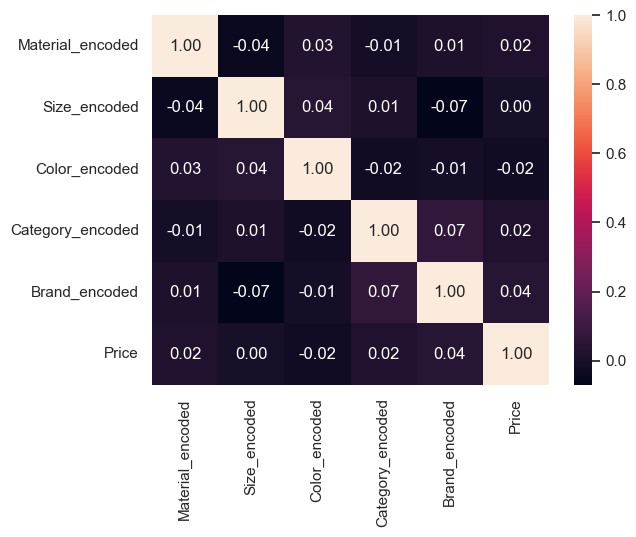

In [140]:
pearson=df3.corr(method='pearson').round(2)
print(pearson)

sns.heatmap(pearson,fmt='.2f',cbar=True,annot=True)
plt.show()

                  Material_encoded  Size_encoded  Color_encoded  \
Material_encoded              1.00         -0.04           0.03   
Size_encoded                 -0.04          1.00           0.04   
Color_encoded                 0.03          0.04           1.00   
Category_encoded             -0.01          0.01          -0.02   
Brand_encoded                 0.02         -0.07          -0.01   
Price                         0.02          0.00          -0.02   

                  Category_encoded  Brand_encoded  Price  
Material_encoded             -0.01           0.02   0.02  
Size_encoded                  0.01          -0.07   0.00  
Color_encoded                -0.02          -0.01  -0.02  
Category_encoded              1.00           0.07   0.02  
Brand_encoded                 0.07           1.00   0.03  
Price                         0.02           0.03   1.00  


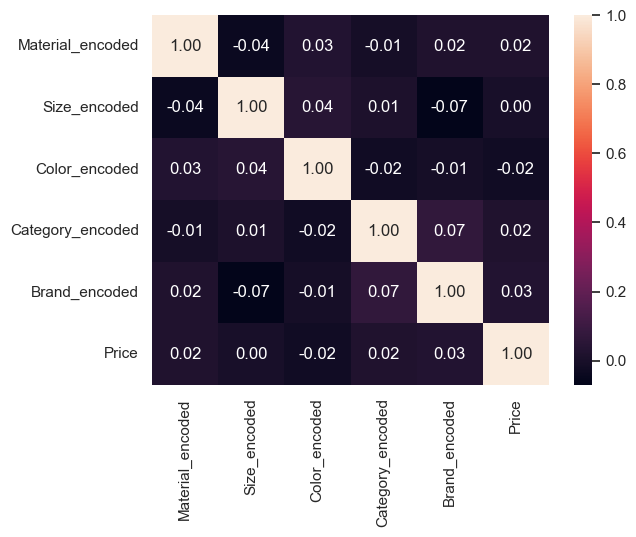

In [139]:
spearman=df3.corr(method='spearman').round(2)
print(spearman)

sns.heatmap(spearman,fmt='.2f',cbar=True,annot=True)
plt.show()

In [141]:
df3.columns

Index(['Material_encoded', 'Size_encoded', 'Color_encoded', 'Category_encoded',
       'Brand_encoded', 'Price'],
      dtype='object')

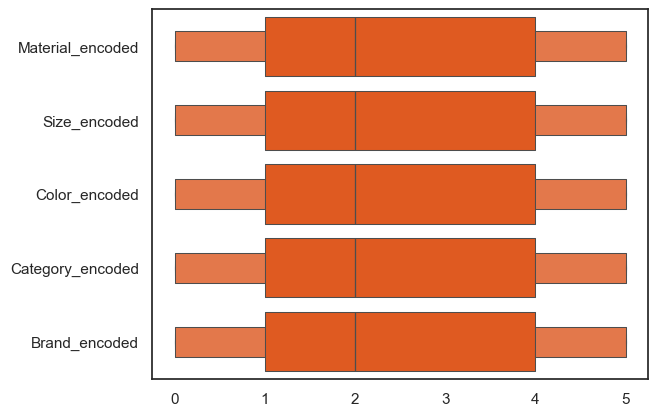

In [150]:

cl1=['#ff4d01']


sns.set_theme(style='white',palette=cl1)
sns.boxenplot(df3[['Material_encoded', 'Size_encoded', 'Color_encoded', 'Category_encoded',
       'Brand_encoded']],palette=cl1,orient='h')

plt.savefig("p6.png",dpi=100)
plt.show()

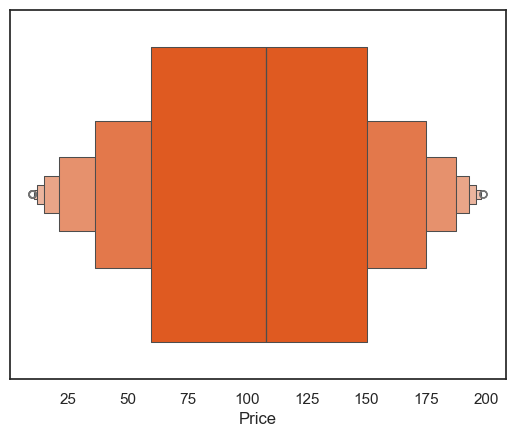

In [157]:
cl1=['#ff4d01']


sns.set_theme(style='white',palette=cl1)
sns.boxenplot(df3['Price'],palette=cl1,orient='h')

plt.savefig("p7.png",dpi=100)
plt.show()

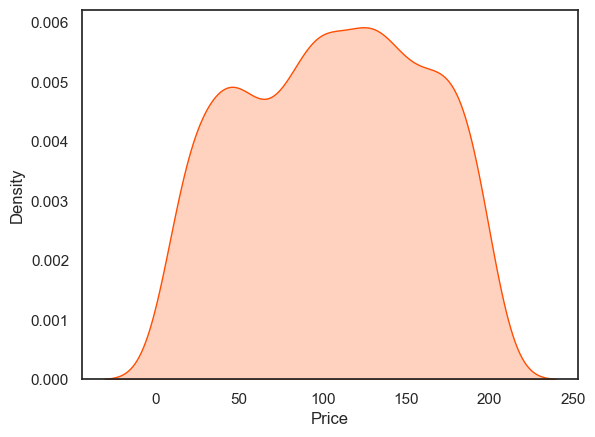

In [156]:
cl1=['#ff4d01']


sns.set_theme(style='white',palette=cl1)
sns.kdeplot(df3['Price'],fill=True,palette=cl1)

plt.savefig("p8.png",dpi=100)
plt.show()

In [158]:
df3.isna().sum()

Material_encoded    0
Size_encoded        0
Color_encoded       0
Category_encoded    0
Brand_encoded       0
Price               0
dtype: int64

In [159]:
df3.isnull().sum()

Material_encoded    0
Size_encoded        0
Color_encoded       0
Category_encoded    0
Brand_encoded       0
Price               0
dtype: int64

In [161]:
class AnomoliesInterClass:
    def __init__(self,data):
        self.data=data
    def anomolies_function(self,col):
        Q1=self.data[col].quantile(0.25)
        Q3=self.data[col].quantile(0.75)
        IQR=Q3-Q1
        lower_bound=Q1-1.5*IQR 
        upper_bound=Q3+1.5*IQR 
        mask=(self.data[col]<lower_bound) | (self.data[col]>upper_bound)
        anomolies_indexes=self.data[col][mask].index.to_list()
        anomolies_data=self.data[col][mask].to_list()
        return anomolies_indexes, list(anomolies_data)
    
num_col=df3.select_dtypes(include='number',exclude='object').columns
AnomoliesInterClass_Instance=AnomoliesInterClass(df3)
anomolies_index_store=set()

for each_col in num_col:
    anomolies_indexes,anomolies_data=AnomoliesInterClass_Instance.anomolies_function(each_col)
    total_anomolies=len(anomolies_data)
    print(f"anomolies length is {total_anomolies}")
    if anomolies_indexes:
        print(f"{each_col} --> {anomolies_indexes}")
        import time 
        time.sleep(2)
        print("anomolies_indexes storing into set")
        anomolies_index_store.update(anomolies_indexes)
    else:
        print(f"{each_col} --> Anomolies not found in this column")
        
df4=df3.drop(list(anomolies_index_store),axis=0)
print(f"old shape is {df3.shape} and new shape is {df4.shape}")       

anomolies length is 0
Material_encoded --> Anomolies not found in this column
anomolies length is 0
Size_encoded --> Anomolies not found in this column
anomolies length is 0
Color_encoded --> Anomolies not found in this column
anomolies length is 0
Category_encoded --> Anomolies not found in this column
anomolies length is 0
Brand_encoded --> Anomolies not found in this column
anomolies length is 0
Price --> Anomolies not found in this column
old shape is (1000, 6) and new shape is (1000, 6)


In [166]:
x=df4.iloc[:,:-1]
y=df4.iloc[:,-1]

In [171]:
best_cols=SelectKBest(score_func=f_regression,k=5)
best_cols.fit_transform(x,y)

new_cols=x.columns[best_cols.get_support()]
new_cols

Index(['Material_encoded', 'Size_encoded', 'Color_encoded', 'Category_encoded',
       'Brand_encoded'],
      dtype='object')

In [176]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [196]:
linear_reg=LinearRegression(n_jobs=-1)
poly=PolynomialFeatures(degree=4,include_bias=True)
decesion_tree=DecisionTreeRegressor(criterion='absolute_error',max_depth=10,min_samples_split=20,min_samples_leaf=20,splitter='random',max_features='sqrt',random_state=12)
random_forest=RandomForestRegressor(criterion='absolute_error',n_estimators=10,n_jobs=-1,min_samples_leaf=10,min_samples_split=20,max_depth=10,max_features='sqrt',random_state=42)

In [ ]:
cross_score1=cross_val_score(linear_reg,x,y,scoring='r2',cv=20)
cross_score2=cross_val_score(poly,x,y,scoring='r2',cv=20)
cross_score3=cross_val_score(decesion_tree,x,y,scoring='r2',cv=20)
cross_score4=cross_val_score(random_forest,x,y,scoring='r2',cv=20)

mean_value=np.mean(cross_score1)
print(abs(mean_value))

mean_value1=np.mean(cross_score3)
print(abs(mean_value1))

mean_value2=np.mean(cross_score4)
print(abs(mean_value2))

0.03470711375066733
0.10599774409264451
0.06801181514903143


In [ ]:

pipeline1=Pipeline(steps=[
    ("LinearRegression",linear_reg)
])
pipeline2=Pipeline(steps=[
    ("polynomolial",poly),
    ('LinearRegression',linear_reg)
])
pipeline3=Pipeline(steps=[
    ("Decesion_tree",decesion_tree)
])

pipeline4=Pipeline(steps=[
    ("random_foreset",random_forest)
])


model_dict={
    "linear_reg":pipeline1,
    "polynomial_reg":pipeline2,
    "decesion_tree":pipeline3,
    "random_foreset":pipeline4
}

for name, model in model_dict.items():
    print("--------------------------------")
    print(f"name of the model is {name}")
    model.fit(x_train, y_train)
    print("--------------------------------")
    y_pred = model.predict(x_test)
    # print(y_pred)
    # Create scatter plot of actual vs predicted
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, label='Predictions')
    
    # Draw the perfect prediction line (best fit would be y=x)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
    
    # Add regression line through predictions
    sns.regplot(x=y_test, y=y_pred,  label='Best Fit Line')
    
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'{name} - Actual vs Predicted')
    plt.legend()
    plt.show()

--------------------------------
name of the model is linear_reg
--------------------------------


TypeError: dump() missing 1 required positional argument: 'filename'